# Sparse Matrix Solver Experiments

Benchmarking linear system solvers (Matrix Inverse, LU, Cholesky, QR, Sparse LU) across matrix types: dense, SPD, sparse, tridiagonal, and Gershgorin.

In [7]:
import time
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import scipy.linalg
import scipy.sparse
import scipy.sparse.linalg


## Solvers

In [1]:
1

1

In [8]:
def solve_matrix_inverse(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    return np.linalg.inv(A) @ b


def solve_lu(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    lu, piv = scipy.linalg.lu_factor(A)
    return scipy.linalg.lu_solve((lu, piv), b)


def solve_cholesky(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    A_sym = (A + A.T) / 2
    c, low = scipy.linalg.cho_factor(A_sym)
    return scipy.linalg.cho_solve((c, low), b)


def solve_qr(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    Q, R = np.linalg.qr(A)
    return np.linalg.solve(R, Q.T @ b)


def solve_sparse_lu(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    return scipy.sparse.linalg.spsolve(scipy.sparse.csc_matrix(A), b)


def run_benchmark(
    fn, methods: dict, realisations: int, max_iterations: int,
    target_seconds: float = 0.3, *args, **kwargs
) -> pl.DataFrame:
    """
    Benchmark each solver on matrices generated by fn.
    Iterations are auto-scaled per solver: a warmup run estimates the solve time,
    then iterations are capped so each solver runs for at most target_seconds total.
    max_iterations is an upper bound.
    """
    records = []
    for _ in range(realisations):
        A, b = fn(*args, **kwargs)
        for name, solver in methods.items():
            # warmup (also primes CPU caches)
            solver(A, b)
            t_single = time.perf_counter()
            solver(A, b)
            t_single = time.perf_counter() - t_single

            n_iters = max(1, min(max_iterations, int(target_seconds / t_single)))

            t = 0.0
            for _ in range(n_iters):
                t0 = time.perf_counter()
                solver(A, b)
                t += time.perf_counter() - t0
            records.append({"Method": name, "ExecutionTime": t / n_iters})
    return pl.DataFrame(records)


## Matrix Generators

In [9]:
def generate_general_dense(n: int) -> tuple[np.ndarray, np.ndarray]:
    A = np.random.randn(n, n) + 5 * np.eye(n)
    b = np.random.randn(n)
    return A, b


def generate_symmetric(n: int) -> tuple[np.ndarray, np.ndarray]:
    lambdas = np.random.uniform(1.0, 10.0, n)
    V = np.tril(np.random.uniform(0, 1, (n, n)) + np.eye(n))
    A = V @ V.T + np.diag(lambdas)
    b = np.random.uniform(-15.0, 15.0, n)
    return A, b


def generate_tridiagonal(n: int) -> tuple[np.ndarray, np.ndarray]:
    A = np.zeros((n, n))
    np.fill_diagonal(A, 2)
    np.fill_diagonal(A[1:], -1)
    np.fill_diagonal(A[:, 1:], -1)
    return A, np.random.randn(n)


In [10]:
def generate_sparse(
    n: int, rho: float, a: float = 5.0, delta: float = 0.01, b_density: float = None
) -> tuple[np.ndarray, np.ndarray]:
    if rho < 1 / n:
        raise ValueError(f"rho must be >= 1/n for invertibility (rho={rho}, 1/n={1/n:.4f})")

    num_offdiag = int(rho * n * n - n)
    diag_flat = np.arange(n) * (n + 1)
    offdiag_flat = np.delete(np.arange(n * n), diag_flat)

    A = np.zeros((n, n))
    if num_offdiag > 0:
        chosen = np.random.choice(offdiag_flat, size=num_offdiag, replace=False)
        rows, cols = np.unravel_index(chosen, (n, n))
        A[rows, cols] = np.random.uniform(-a, a, num_offdiag)

    row_sums = np.abs(A).sum(axis=1)
    np.fill_diagonal(A, row_sums + np.random.uniform(delta, 1, n))

    if b_density is None:
        b_density = rho
    if not (0 <= b_density <= 1):
        raise ValueError(f"b_density must be in [0, 1], got {b_density}")
    num_nonzero_b = int(b_density * n)
    b = np.zeros(n)
    if num_nonzero_b > 0:
        idx = np.random.choice(n, size=num_nonzero_b, replace=False)
        b[idx] = np.random.uniform(-a, a, num_nonzero_b)

    return A, b


def generate_gershgorin(n: int, target_density: float) -> tuple[np.ndarray, np.ndarray]:
    num_offdiag = max(0, min(int(target_density * n * n) - n, n * (n - 1)))

    diag_flat = np.arange(n) * (n + 1)
    offdiag_flat = np.delete(np.arange(n * n), diag_flat)
    chosen = np.random.choice(offdiag_flat, size=num_offdiag, replace=False)
    rows, cols = np.unravel_index(chosen, (n, n))

    A = np.zeros((n, n))
    A[rows, cols] = np.random.uniform(-10, 10, num_offdiag)

    row_sums = np.abs(A).sum(axis=1)
    np.fill_diagonal(A, row_sums + np.random.uniform(0.01, 1, n))

    return A, np.random.randn(n)


## Experiment Definitions

In [11]:
REALISATIONS = 5
MAX_ITERATIONS = 100

METHODS_DENSE   = {"MatrixInverse": solve_matrix_inverse, "LU": solve_lu, "QR": solve_qr}
METHODS_SPD     = {"MatrixInverse": solve_matrix_inverse, "LU": solve_lu, "Cholesky": solve_cholesky, "QR": solve_qr}
METHODS_SPARSE  = {"SparseLU": solve_sparse_lu, "LU": solve_lu, "QR": solve_qr, "MatrixInverse": solve_matrix_inverse}
METHODS_SPARSE4 = {"SparseLU": solve_sparse_lu, "LU": solve_lu, "QR": solve_qr}
METHODS_ALL     = {"SparseLU": solve_sparse_lu, "LU": solve_lu, "Cholesky": solve_cholesky, "MatrixInverse": solve_matrix_inverse, "QR": solve_qr}
METHODS_SPARSE6 = {"SparseLU": solve_sparse_lu, "LU": solve_lu, "Cholesky": solve_cholesky}


def experiment_1_dense(n: int) -> pl.DataFrame:
    return run_benchmark(generate_general_dense, METHODS_DENSE, REALISATIONS, MAX_ITERATIONS, n=n)


def experiment_2_symmetric(n: int) -> pl.DataFrame:
    return run_benchmark(generate_symmetric, METHODS_SPD, REALISATIONS, MAX_ITERATIONS, n=n)


def experiment_3_sparse_dense_b(n: int, density: float) -> pl.DataFrame:
    return run_benchmark(generate_sparse, METHODS_SPARSE, REALISATIONS, MAX_ITERATIONS, n=n, rho=density, b_density=1.0)


def experiment_4_sparse_both(n: int, density: float) -> pl.DataFrame:
    return run_benchmark(generate_sparse, METHODS_SPARSE4, REALISATIONS, MAX_ITERATIONS, n=n, rho=density, b_density=density)


def experiment_5_dense_b(n: int, matrix_type: str) -> pl.DataFrame:
    if matrix_type == "tridiagonal":
        return run_benchmark(generate_tridiagonal, METHODS_ALL, REALISATIONS, MAX_ITERATIONS, n=n)
    density = (3 * n - 2) / (n ** 2)
    return run_benchmark(generate_gershgorin, METHODS_ALL, REALISATIONS, MAX_ITERATIONS, n=n, target_density=density)


def experiment_6_sparse_b(n: int, matrix_type: str) -> pl.DataFrame:
    b_density = (3 * n - 2) / (n ** 2)
    num_nonzero_b = max(1, int(b_density * n))

    def _with_sparse_b(generator, **kw):
        def _gen(n):
            A, _ = generator(n=n, **kw)
            idx = np.random.choice(n, size=num_nonzero_b, replace=False)
            b = np.zeros(n)
            b[idx] = np.random.randn(num_nonzero_b)
            return A, b
        return _gen

    if matrix_type == "tridiagonal":
        fn = _with_sparse_b(generate_tridiagonal)
    else:
        density = (3 * n - 2) / (n ** 2)
        fn = _with_sparse_b(generate_gershgorin, target_density=density)

    return run_benchmark(fn, METHODS_SPARSE6, REALISATIONS, MAX_ITERATIONS, n=n)


## Experiment Runners

In [ ]:
def run_experiment_1_2() -> pl.DataFrame:
    print("Experiments 1 & 2: Dense and SPD matrices")
    dimensions = [50, 100,200,400]
    frames = []
    for d in dimensions:
        print(f"  n={d}")
        frames.append(experiment_1_dense(d).with_columns(
            pl.lit(d).alias("Dimension"),
            pl.lit("General Dense").alias("MatrixType"),
            pl.lit("Exp1: Dense").alias("Experiment"),
            pl.lit(1.0).alias("Density"),
        ))
        frames.append(experiment_2_symmetric(d).with_columns(
            pl.lit(d).alias("Dimension"),
            pl.lit("SPD").alias("MatrixType"),
            pl.lit("Exp2: SPD").alias("Experiment"),
            pl.lit(1.0).alias("Density"),
        ))
    return pl.concat(frames)


In [13]:
def run_experiment_3() -> pl.DataFrame:
    print("Experiment 3: Sparse A, dense b")
    densities = [0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 1.0]
    n = 200
    frames = []
    for rho in densities:
        print(f"  rho={rho:.2f}")
        frames.append(experiment_3_sparse_dense_b(n, rho).with_columns(
            pl.lit(n).alias("Dimension"),
            pl.lit("Sparse").alias("MatrixType"),
            pl.lit("Exp3: Sparse A, Dense b").alias("Experiment"),
            pl.lit(rho).alias("Density"),
        ))
    return pl.concat(frames)


In [14]:
def run_experiment_4() -> pl.DataFrame:
    print("Experiment 4: Sparse A, sparse b")
    densities = [0.01, 0.05, 0.1, 0.2, 0.5]
    n = 200
    frames = []
    for rho in densities:
        print(f"  rho={rho:.2f}")
        frames.append(experiment_4_sparse_both(n, rho).with_columns(
            pl.lit(n).alias("Dimension"),
            pl.lit("Sparse").alias("MatrixType"),
            pl.lit("Exp4: Sparse A, Sparse b").alias("Experiment"),
            pl.lit(rho).alias("Density"),
        ))
    return pl.concat(frames)


In [15]:
def run_experiment_5() -> pl.DataFrame:
    print("Experiment 5: Tridiagonal and Gershgorin (dense b)")
    dimensions = [100, 200, 400, 800]
    frames = []
    for n in dimensions:
        print(f"  n={n}")
        density = (3 * n - 2) / (n ** 2)
        for mtype in ("tridiagonal", "gershgorin"):
            frames.append(experiment_5_dense_b(n, mtype).with_columns(
                pl.lit(n).alias("Dimension"),
                pl.lit(density).alias("Density"),
                pl.lit(mtype.capitalize()).alias("MatrixType"),
                pl.lit("Exp5: Dense b").alias("Experiment"),
            ))
    return pl.concat(frames)


def run_experiment_6() -> pl.DataFrame:
    print("Experiment 6: Tridiagonal and Gershgorin (sparse b)")
    dimensions = [100, 200, 400, 800]
    frames = []
    for n in dimensions:
        print(f"  n={n}")
        density = (3 * n - 2) / (n ** 2)
        for mtype in ("tridiagonal", "gershgorin"):
            frames.append(experiment_6_sparse_b(n, mtype).with_columns(
                pl.lit(n).alias("Dimension"),
                pl.lit(density).alias("Density"),
                pl.lit(mtype.capitalize()).alias("MatrixType"),
                pl.lit("Exp6: Sparse b").alias("Experiment"),
            ))
    return pl.concat(frames)


## Plotting

In [16]:
def _errorbar_grouped(ax, data: pl.DataFrame, x_col: str, hue_col: str, **kwargs):
    """Plot mean ± std errorbar lines, one per unique value of hue_col."""
    for label in data[hue_col].unique(maintain_order=True):
        subset = data.filter(pl.col(hue_col) == label)
        grouped = subset.group_by(x_col).agg(
            pl.col("ExecutionTime").mean().alias("Mean"),
            pl.col("ExecutionTime").std().alias("Std"),
        ).sort(x_col)
        ax.errorbar(
            grouped[x_col].to_numpy(),
            grouped["Mean"].to_numpy(),
            yerr=grouped["Std"].to_numpy(),
            label=label, capsize=4, alpha=0.8, **kwargs
        )


def create_plots(results: pl.DataFrame, save_dir: str = "plots"):
    Path(save_dir).mkdir(exist_ok=True)

    def _log_axes(ax, xlabel, ylabel, title):
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Execution time (s)")
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    # Exp 1 & 2: time vs dimension
    exp1_2 = results.filter(pl.col("Experiment").is_in(["Exp1: Dense", "Exp2: SPD"]))
    if len(exp1_2) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, exp_name in zip(axes, ["Exp1: Dense", "Exp2: SPD"]):
            _errorbar_grouped(ax, exp1_2.filter(pl.col("Experiment") == exp_name),
                              x_col="Dimension", hue_col="Method", marker="o")
            _log_axes(ax, "Matrix dimension", "Execution time (s)", exp_name)
        fig.tight_layout()
        fig.savefig(f"{save_dir}/exp1_2_time_vs_size.pdf", bbox_inches="tight")
        plt.show()
        plt.close(fig)

    # Exp 3: time vs density (sparse A, dense b)
    exp3 = results.filter(pl.col("Experiment") == "Exp3: Sparse A, Dense b")
    if len(exp3) > 0:
        fig, ax = plt.subplots(figsize=(8, 5))
        _errorbar_grouped(ax, exp3, x_col="Density", hue_col="Method", marker="s")
        _log_axes(ax, "Matrix density", "Execution time (s)", "Exp3: Sparse A, Dense b")
        fig.tight_layout()
        fig.savefig(f"{save_dir}/exp3_time_vs_density.pdf", bbox_inches="tight")
        plt.show()
        plt.close(fig)

    # Exp 3 & 4 side-by-side
    exp4 = results.filter(pl.col("Experiment") == "Exp4: Sparse A, Sparse b")
    if len(exp3) > 0 and len(exp4) > 0:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        _errorbar_grouped(ax1, exp3.filter(pl.col("Method") != "MatrixInverse"),
                          x_col="Density", hue_col="Method", marker="o")
        _log_axes(ax1, "Matrix density", "Execution time (s)", "Sparse A, dense b")
        _errorbar_grouped(ax2, exp4, x_col="Density", hue_col="Method", marker="s")
        _log_axes(ax2, "Matrix density", "Execution time (s)", "Sparse A, sparse b")
        fig.tight_layout()
        fig.savefig(f"{save_dir}/exp3_4_comparison.pdf", bbox_inches="tight")
        plt.show()
        plt.close(fig)

    # Exp 5: tridiagonal vs Gershgorin (dense b)
    exp5 = results.filter(pl.col("Experiment") == "Exp5: Dense b")
    if len(exp5) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, mtype in zip(axes, ["Tridiagonal", "Gershgorin"]):
            _errorbar_grouped(ax, exp5.filter(pl.col("MatrixType") == mtype),
                              x_col="Dimension", hue_col="Method", marker="o")
            _log_axes(ax, "Matrix dimension", "Execution time (s)", f"Exp5: {mtype} (dense b)")
        fig.tight_layout()
        fig.savefig(f"{save_dir}/exp5_special_matrices.pdf", bbox_inches="tight")
        plt.show()
        plt.close(fig)

    # Exp 6: tridiagonal vs Gershgorin (sparse b)
    exp6 = results.filter(pl.col("Experiment") == "Exp6: Sparse b")
    if len(exp6) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, mtype in zip(axes, ["Tridiagonal", "Gershgorin"]):
            _errorbar_grouped(ax, exp6.filter(pl.col("MatrixType") == mtype),
                              x_col="Dimension", hue_col="Method", marker="s")
            _log_axes(ax, "Matrix dimension", "Execution time (s)", f"Exp6: {mtype} (sparse b)")
        fig.tight_layout()
        fig.savefig(f"{save_dir}/exp6_special_matrices.pdf", bbox_inches="tight")
        plt.show()
        plt.close(fig)


## Summary Statistics

In [17]:
def compute_stats(results: pl.DataFrame) -> pl.DataFrame:
    return results.group_by(["Experiment", "Method", "Dimension"]).agg(
        pl.col("ExecutionTime").mean().alias("MeanTime"),
        pl.col("ExecutionTime").std().alias("StdTime"),
        pl.col("ExecutionTime").min().alias("MinTime"),
        pl.col("ExecutionTime").max().alias("MaxTime"),
        pl.len().alias("Samples"),
    )


def print_summary_statistics(results: pl.DataFrame):
    for exp in sorted(results["Experiment"].unique()):
        print(f"\n{exp}:")
        stats = (
            results.filter(pl.col("Experiment") == exp)
            .group_by("Method")
            .agg(
                pl.col("ExecutionTime").mean().alias("MeanTime"),
                pl.col("ExecutionTime").std().alias("StdTime"),
                pl.col("Dimension").mean().alias("AvgDim"),
                pl.len().alias("Samples"),
            )
            .sort("MeanTime")
        )
        for row in stats.iter_rows(named=True):
            print(
                f"  {row['Method']:15s}: {row['MeanTime']:.6f} \u00b1 {row['StdTime']:.6f} s"
                f"  (n={row['Samples']}, avg dim={row['AvgDim']:.0f})"
            )


## Run Experiments

In [ ]:
Path("results").mkdir(exist_ok=True)
Path("plots").mkdir(exist_ok=True)

experiments_to_run = [
    ("1 & 2", run_experiment_1_2),
    ("3",     run_experiment_3),
    ("4",     run_experiment_4),
    # ("5",  run_experiment_5),
    # ("6",  run_experiment_6),
]

all_results = []
for name, fn in experiments_to_run:
    result = fn()
    all_results.append(result)
    print(f"  -> {len(result)} records")

combined_results = pl.concat(all_results)


Experiments 1 & 2: Dense and SPD matrices
  n=50
  n=100
  -> 70 records
Experiment 3: Sparse A, dense b
  rho=0.01
  rho=0.05
  rho=0.10
  rho=0.20
  rho=0.50
  rho=0.80
  rho=1.00
  -> 140 records


In [19]:
print_summary_statistics(combined_results)



Exp1: Dense:
  LU             : 0.000134 ± 0.000058 s  (n=10, avg dim=75)
  QR             : 0.013558 ± 0.014677 s  (n=10, avg dim=75)
  MatrixInverse  : 0.018550 ± 0.023839 s  (n=10, avg dim=75)

Exp2: SPD:
  LU             : 0.000096 ± 0.000035 s  (n=10, avg dim=75)
  Cholesky       : 0.000116 ± 0.000033 s  (n=10, avg dim=75)
  MatrixInverse  : 0.007472 ± 0.007092 s  (n=10, avg dim=75)
  QR             : 0.009207 ± 0.008587 s  (n=10, avg dim=75)


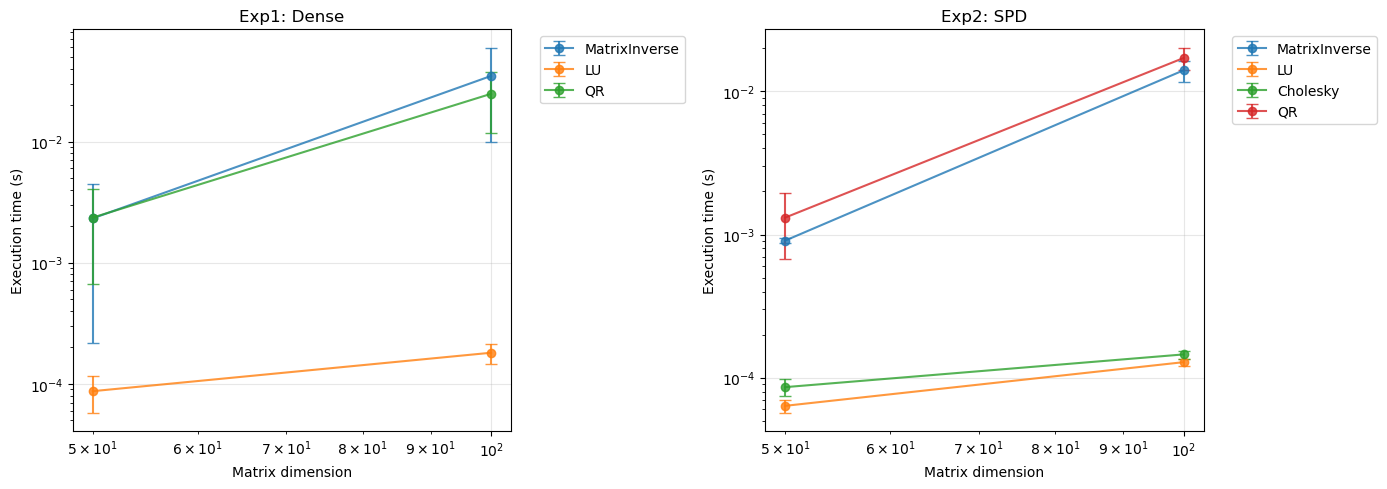

In [20]:
create_plots(combined_results)
